In [1]:
import pandas as pd
import numpy as np

In [2]:
np.random.seed (200804)

In [23]:
titanic = pd.read_csv("./titanic.csv")

In [24]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
titanic.rename(columns={col: col.lower().replace('/',"_").replace(" ","_")
                            for col in titanic.columns.values}, inplace=True)
titanic.head ()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [26]:
titanic.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [30]:
#titanic.sex.mask (titanic.sex == 'female', '1', inplace=True)
#titanic.sex.mask (titanic.sex == 'male', '0', inplace=True)
titanic.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [33]:
# variables explicativas y variable target
X = titanic[['pclass','sex','age','sibsp','parch','fare']]
y = titanic[['survived' ]]

In [34]:
from sklearn.model_selection import train_test_split
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)
print("\nX train, y_train: ", (X_train.shape, y_train.shape))
print("\nX test, y_test: ", (X_test.shape, y_test.shape))


X train, y_train:  ((623, 6), (623, 1))

X test, y_test:  ((268, 6), (268, 1))


In [ ]:
import matplotlib.pyplot as plt
from sklearn. ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [42]:
rf = RandomForestClassifier(n_jobs=-1, oob_score=True)

grid = {"n_estimators": [600,800,1000], 'criterion': ['gini', 'entropy'],
        'min_samples_leaf': [5,7,9,11]}


gs = GridSearchCV(
    rf,
    param_grid=grid,
    scoring='precision',
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

#y_train = y_train.values.ravel()
gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ob_score=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'min_samples_leaf': [5, 7, ...], 'n_estimators': [600, 800, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is di

In [43]:
best_model = gs.best_estimator_

In [44]:
type(best_model)

sklearn.ensemble._forest.RandomForestClassifier

In [45]:
best_model.oob_score_

0.8073836276083467

In [46]:
gs.best_score_

np.float64(0.7955337690631809)

### Feautere importance

In [47]:
best_model.feature_importances_

array([0.10301848, 0.4738006 , 0.16213506, 0.03118967, 0.03113977,
       0.19871641])

In [49]:
X.columns.values

array(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare'], dtype=object)

### Predicciones

In [50]:
#obtener las etiquetas del mejor predictor
predicted_labels = gs.predict(X_test)
predicted_labels[:10]

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 1])

In [51]:
predicted_score = gs.predict_proba(X_test)
predicted_score[:10]

array([[0.33999084, 0.66000916],
       [0.1581269 , 0.8418731 ],
       [0.05198131, 0.94801869],
       [0.94457953, 0.05542047],
       [0.83659053, 0.16340947],
       [0.78481989, 0.21518011],
       [0.51904181, 0.48095819],
       [0.10267987, 0.89732013],
       [0.95313211, 0.04686789],
       [0.15011514, 0.84988486]])

#### Metricas de desempeño

###### Accuracy

In [53]:
from sklearn.metrics import accuracy_score

In [54]:
accuracy = accuracy_score(y_test, predicted_labels)
accuracy

0.8246268656716418

ROC y AUC

In [55]:
from sklearn.metrics import roc_auc_score, roc_curve

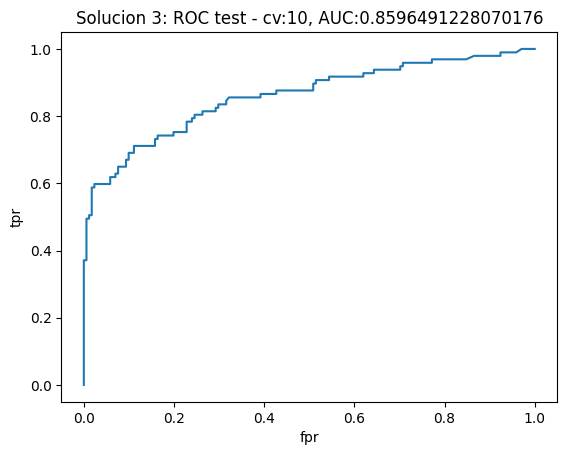

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, predicted_score[:,1], pos_label=1)

plt.clf()
plt.plot([0,1], [0,1], 'k--', c= "red")
plt.plot(fpr,tpr)
plt.title("Solucion 3: ROC test - cv:10, AUC:" + str(roc_auc_score(y_test, predicted_score[:,1])))
plt.xlabel("fpr")
plt.ylabel("tpr")
plt.show()